In [1]:
import gc

# Clear GPU memory
import cupy as cp
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

# Clear CPU memory
gc.collect()

import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux


import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")


# GPU configuration
use_gpu = True
dt = 10     # Time step
T = 0.25   # Total time
force_backend = "cuda12x"  # Force GPU

# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
        "err": 1e-15  # Error tolerance 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend  # Force GPU
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}



# waveform_class = FastKerrEccentricEquatorialFlux
# waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
#                              amplitude_kwargs=amplitude_kwargs,
#                              Ylm_kwargs=Ylm_kwargs,
#                              sum_kwargs=sum_kwargs,
#                              use_gpu=use_gpu)

 
#waveform generator setup
# waveform_generator = GenerateEMRIWaveform
# waveform_generator_kwargs = dict(frame='detector')

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)
gwf = GWfuncs.GravWaveAnalysis(T, dt)

# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5


Creating GenerateEMRIWaveform class...


In [ ]:
# varying over logm1
x = np.array([5.99999822, 5.99999829, 5.99999836, 5.99999843, 5.99999851,
       5.99999858, 5.99999865, 5.99999873, 5.9999988 , 5.99999887,
       5.99999894, 5.99999902, 5.99999909, 5.99999916, 5.99999924,
       5.99999931, 5.99999938, 5.99999945, 5.99999953, 5.9999996 ,
       5.99999967, 5.99999975, 5.99999982, 5.99999989, 5.99999996,
       6.00000004, 6.00000011, 6.00000018, 6.00000025, 6.00000033,
       6.0000004 , 6.00000047, 6.00000055, 6.00000062, 6.00000069,
       6.00000076, 6.00000084, 6.00000091, 6.00000098, 6.00000106,
       6.00000113, 6.0000012 , 6.00000127, 6.00000135, 6.00000142,
       6.00000149, 6.00000157, 6.00000164, 6.00000171, 6.00000178])

In [3]:
import loglikebasic

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
loglike_obj = loglikebasic.LogLike(params_star, waveform_gen_comb, gwf, M_init=5, verbose=True, waveform_gen_sep=waveform_gen_sep, noise_weighted=True)
def fstat(params):
    logm1, logm2, a, p0, e0 = params
    m1 = 10**logm1
    m2 = 10**logm2

    loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
    
    return loglike

Delta_T for mode selection: 1577.9074881772797 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, -1) with power 9.974322381817613e+40
Considering mode 1 / 5 : (2, -2, 0) with power 6.642690878968553e+40
 - Overlap with selected mode 0: 1.3756183678931474e-05
Considering mode 2 / 5 : (2, -2, 1) with power 1.6105119343067213e+40
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 4.104610127803453e-06
Considering mode 3 / 5 : (3, -3, -1) with power 1.037050715512486e+40
 - Overlap with selected mode 0: 1.0738379849810786e-05
 - Overlap with selected mode 1: 2.5018562146918954e-06
 - Overlap with selected mode 2: 0.0
Considering mode 4 / 5 : (3, -3, 1) with power 8.643527711562299e+39
 - Overlap with selected mode 0: 4.211376084638782e-06
 - Overlap with selected mode 1: 1.0763006452275218e-06
 - Overlap with selected mode 2: 2.0388460867456177e-06
 - Overlap with selected mode 3: 0.0
Final selected labels: [[(2, -2, -1)], [(2, -2, 0)], [(2, -2

In [4]:
f_vals = []
for val in x:
    param = [val, np.log10(m2), a, p0, e0]
    calc_fstat = fstat(param)
    # print(calc_fstat)
    f_vals.append(calc_fstat)


Evaluating log-likelihood at parameters: [9.99995901e+05 3.00000000e+01 7.00000000e-01 7.50000000e+00
 4.00000000e-01 1.00000000e+00 5.00000000e-01 5.00000000e-01
 1.00000000e+00 1.00000000e+00 2.04719755e+00 4.00000000e-01
 0.00000000e+00 5.00000000e-01]
Using selected modes: [[(2, -2, -1)], [(2, -2, 0)], [(2, -2, 1)], [(3, -3, -1)], [(3, -3, 1)]]
Waveform amplitudes:
  Mode 0: max(|h|) = 7.052282231879099e-22, <hf|hf> = 4363.90018848384, rho = 66.05982280088132
  Mode 1: max(|h|) = 7.113714350361531e-22, <hf|hf> = 1728.9145841541522, rho = 41.58021866409738
  Mode 2: max(|h|) = 5.222628261035924e-22, <hf|hf> = 231.78265861343738, rho = 15.224409959451217
  Mode 3: max(|h|) = 2.268154906550779e-22, <hf|hf> = 281.0920247748391, rho = 16.76579925845586
  Mode 4: max(|h|) = 1.882040650546137e-22, <hf|hf> = 198.00026617608793, rho = 14.071256737622548
Individual rho values: [66.0598228  41.58021866 15.22440996 16.76579926 14.07125674]
Max rho: 66.05982280088132, Min rho: 14.07125673762254

In [5]:
f_vals

[11.476120110694486,
 14.581027057571877,
 18.159040953127363,
 22.1800465613645,
 27.24510362183499,
 31.997010957683777,
 36.9426120408412,
 42.68777974821417,
 47.66657948556031,
 52.4849153734406,
 57.045348839804745,
 61.840359254442525,
 65.60746829769127,
 68.93943674105094,
 72.20093269358506,
 74.58649405417172,
 76.56073550603307,
 78.15962136307954,
 79.58234669812701,
 80.5246410637472,
 81.2318242898247,
 81.80525536806647,
 82.14138388480633,
 82.35213580938759,
 82.45666533206811,
 82.45851908772904,
 82.35717299507067,
 82.14943754987024,
 81.816061469208,
 81.24534632009579,
 80.54009298533316,
 79.59927306460573,
 78.17766922113105,
 76.57930553811508,
 74.60522694758875,
 72.21956804053993,
 68.95780067470473,
 65.62560766539943,
 61.85842396687416,
 57.063648126220045,
 52.503769893180376,
 47.68632021897816,
 42.70867679975222,
 36.96500520952972,
 32.02067854421744,
 27.269816861992442,
 22.205448269096692,
 18.184449511133913,
 14.605810669788529,
 11.49964875273

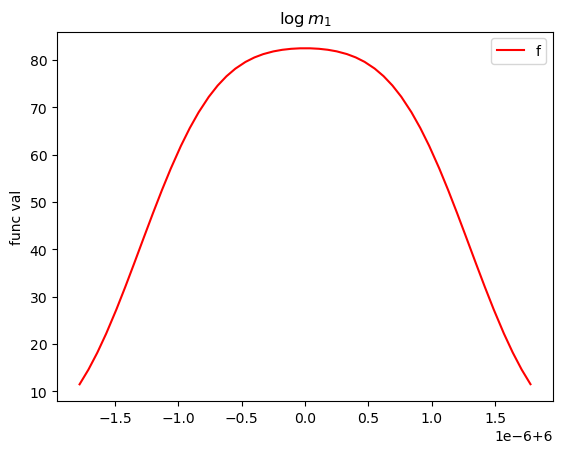

In [7]:
plt.plot(x, f_vals, c='r',label=r'f')
# plt.ylim(-40,5)
plt.legend()
plt.ylabel(r'func val')
plt.title(r'$\log m_1$')
plt.show()

In [8]:
waveform = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,  T=T, dt=dt)

In [9]:
def loglike(params):
    logm1, logm2, a, p0, e0 = params
    m1 = 10**logm1
    m2 = 10**logm2
    phiK = phiS + np.pi/3

    htemp = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
    
  
    res = waveform - htemp

    res_f = gwf.freq_wave(res)
    inner_res = gwf.inner(res_f, res_f)

    calc_loglike = - 0.5 * inner_res
        

    return calc_loglike


loglike_vals = []
for val in x:
    param = [val, np.log10(m2), a, p0, e0]
    calc_loglike = loglike(param)
    print(calc_loglike)
    loglike_vals.append(calc_loglike)


-4192.924740419637
-3919.229346890676
-3649.54165060725
-3384.5384104584796
-3088.2864780145287
-2835.6135568926275
-2589.7631995898087
-2318.0098571807557
-2089.038588655692
-1868.9773081936194
-1658.4643842555488
-1430.3651379361668
-1242.375440877369
-1065.8095740389826
-878.7047820502066
-728.4107216050159
-591.1429207092824
-467.3391738152851
-342.8449550793818
-249.18064528739424
-170.08908405894832
-97.87440060799223
-50.82469780941396
-19.002688405479958
-2.5142488809846095
-2.514247950564289
-19.002669190506815
-50.82461362262435
-97.87417545863357
-170.088567189289
-249.17972709537327
-342.84346976940776
-467.33680240818006
-591.1395365626914
-728.4060764007876
-878.6986033846039
-1065.8012786977135
-1242.3649505445273
-1430.3521111338416
-1658.4480143357246
-1868.957604486677
-2089.0151512641264
-2317.982270550215
-2589.7303438115728
-2835.575613723572
-3088.242990310672
-3384.48801342091
-3649.4846951748227
-3919.1653473422166
-4192.853203368644


In [10]:
loglike_vals_new = [ll.get() for ll in loglike_vals]

In [17]:
f_vals_new = [ff-85 for ff in f_vals]

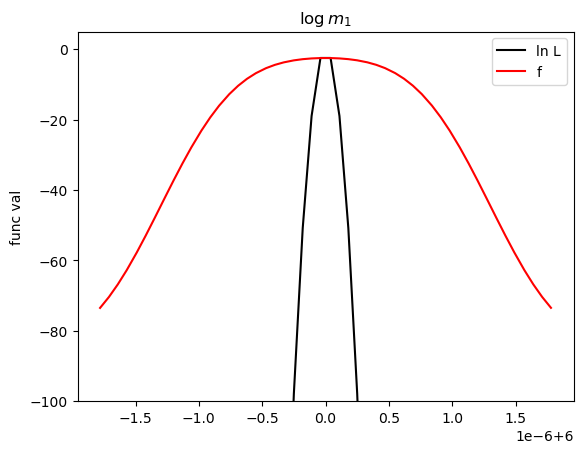

In [20]:
# NOTE: do not normalize
plt.plot(x, loglike_vals_new, c='k', label='ln L')
plt.plot(x, f_vals_new, cs='r',label=r'f')
# plt.plot(x, X_vals_new, c='grey',linestyle='dashed', label=r'X')
plt.ylim(-100,5)
plt.legend()
plt.ylabel(r'func val')
plt.title(r'$\log m_1$')
plt.show()